# Faster_Is_Slower_Demo.ipynb

In crowd physics, the [Faster-is-Slower](https://www.sciencedirect.com/science/article/pii/S2352146514001215) effect occurs when agents try to move too quickly through a bottleneck, leading to high pressures and "clogging" that increases the total evacuation time.

In [ ]:
from jupedsim_scenario import load_scenario, run_scenario

## 1. Setup
We use a scenario with a clear bottleneck (e.g., a narrow door).

In [ ]:
scenario = load_scenario("scenarios/jps_2026_03_07_10_54_07.zip")

v0_values = [0.8, 1.2, 1.6, 2.0, 2.4]
evac_times = []
scenario.set_agent_count(count=67, distribution_id='jps-distributions_0')
print(scenario.summary())

## 2. Parameter Sweep (Desired Speed $v_0$)
We vary the $v_0$ parameter (desired walking speed) for the agent distribution.

In [ ]:

for v0 in v0_values:
    # Set the desired speed for the specific agent distribution group
    scenario.set_agent_params("jps-distributions_0", v0=v0)
    
    # Run simulation
    r = run_scenario(scenario)
    evac_times.append(r.evacuation_time)
    
    print(f"Testing v0 = {v0} m/s... Result: {r.evacuation_time:.2f}s")
    r.cleanup() #

## 3. Analysis
We plot $v_0$ against evacuation time. If the curve starts to trend upward as $v_0$ increases, 
we have successfully replicated the Faster-is-Slower effect.

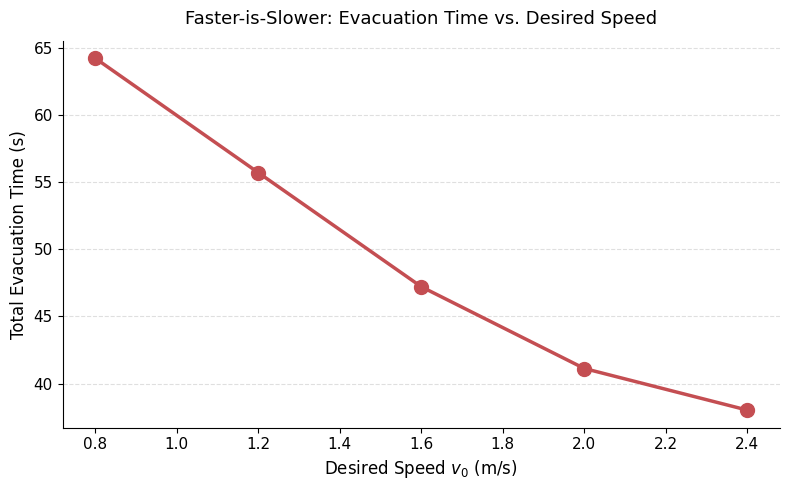

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    v0_values,
    evac_times,
    marker="o",
    color="#C44E52",
    linewidth=2.5,
    markersize=10
)
plt.xlabel("Desired Speed $v_0$ (m/s)", fontsize=12)
plt.ylabel("Total Evacuation Time (s)", fontsize=12)
plt.title("Faster-is-Slower: Evacuation Time vs. Desired Speed", fontsize=13, pad=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.4)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()